# Volatility Signature and Frequency Arbitrage

**Panagiotis Housos · ph2606**
Statistical Arbitrage · Fall 2026

This notebook implements the daily and intraday volatility signatures, their
rolling distributions, and a self-financing frequency-arbitrage strategy.
The accompanying LaTeX report develops the economic interpretation.
All tables and figures below are generated from the downloaded observations.

## 1. Reproducible analysis and data coverage

Execute the notebook from the repository root after following the README's
data-acquisition instructions. Source responses and derived data remain local;
saved notebook outputs preserve the analyzed results. Before writing results,
the analysis checks all 14 input hashes across the daily/hourly and minute
manifests and requires the documented daily
FX sources. It clips hourly timestamps to the stated UTC interval before
determining six-month rolling-window eligibility. The data audit records
actual sample coverage, including the shorter available intraday history.
Following the instructor's clarification, genuine one-minute and five-minute
observations supplement the longer hourly history, with their source and
date ranges stated explicitly.

In [1]:
from pathlib import Path
import os
import subprocess
import sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
assert (ROOT / 'src' / 'analysis.py').is_file(), 'Run from the repository root.'
sys.path.insert(0, str(ROOT))
from src import analysis

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 150)
pd.options.display.float_format = '{:,.5f}'.format
OUT = ROOT / 'outputs'

# Recalculate exhibits from the local observations using the same analysis code.
run = subprocess.run([sys.executable, 'scripts/run_analysis.py'],
                     capture_output=True, text=True, encoding='utf-8', errors='replace')
if run.returncode:
    raise RuntimeError(run.stdout[-4000:] + '\n' + run.stderr[-4000:])
print('Analysis recalculated successfully from the local observations.')

def table(name):
    frame = pd.read_csv(OUT / (name + '.csv'))
    assert not frame.empty, name + ' is empty.'
    display(frame)
    return frame

def figure(name):
    candidates = [ROOT / 'report' / 'figures' / name,
                  ROOT / 'figures' / name, OUT / 'figures' / name, OUT / name]
    path = next((p for p in candidates if p.is_file()), None)
    if path is None:
        raise FileNotFoundError(name)
    display(Image(filename=str(path), width=1050))

audit = table('data_audit')

Analysis recalculated successfully from the local observations.


,asset,frequency,period,first,last,n_prices,retained_sessions,rejected_sessions,n_rolling_windows,source_file,min_window_days,max_window_days,min_window_sessions,max_window_sessions
0,SPY,daily,2000–2007,2000-01-03,2007-12-31,2010,2010,0,1758,SPY_daily.csv,365,NaN,NaN,NaN
1,SPY,daily,2007–2014,2007-01-03,2014-12-31,2014,2014,0,1762,SPY_daily.csv,365,NaN,NaN,NaN
2,SPY,daily,2020–2025,2020-01-02,2025-12-31,1508,1508,0,1256,SPY_daily.csv,364,NaN,NaN,NaN
3,USDJPY,daily,2000–2007,2000-01-03,2007-12-31,2013,2013,0,1761,USDJPY_FRED_daily.csv,365,NaN,NaN,NaN
4,USDJPY,daily,2007–2014,2007-01-02,2014-12-31,2011,2011,0,1759,USDJPY_FRED_daily.csv,360,NaN,NaN,NaN
5,USDJPY,daily,2020–2025,2020-01-02,2025-12-31,1499,1499,0,1247,USDJPY_FRED_daily.csv,370,NaN,NaN,NaN
6,EURUSD,daily,2000–2007,2000-01-03,2007-12-31,2013,2013,0,1761,EURUSD_FRED_daily.csv,365,NaN,NaN,NaN
7,EURUSD,daily,2007–2014,2007-01-02,2014-12-31,2011,2011,0,1759,EURUSD_FRED_daily.csv,360,NaN,NaN,NaN
8,EURUSD,daily,2020–2025,2020-01-02,2025-12-31,1499,1499,0,1247,EURUSD_FRED_daily.csv,370,NaN,NaN,NaN
9,SPY,intraday,2024-10–2025-12,2024-10-01,2025-12-31,2178,309,5,187,SPY_hourly.csv,181,184.00000,119.00000,128.00000


SPY daily signatures use Yahoo Finance's dividend-adjusted closing prices.
Both daily currency signatures use Federal Reserve H.10 noon New York buying
rates from FRED: [DEXUSEU](https://fred.stlouisfed.org/series/DEXUSEU) for USD per
euro and [DEXJPUS](https://fred.stlouisfed.org/series/DEXJPUS) for JPY per dollar.
These provide the full required history without splicing sources. Yahoo's
early currency coverage and anomalous observations make it unsuitable for
the complete daily comparison. The backtests instead use Yahoo's observed
2020–2025 execution closes, with dividend cash flows handled separately.

Intraday estimates use observed Yahoo hourly, one-minute and five-minute prices.
No missing interval is
filled with an invented return. The daily grids count available observation
dates: currency and equity holiday calendars differ. The assignment's
252-session annualization is used consistently, including for currencies.
Equity and foreign-exchange trading hours are treated separately.

**Investment implication.** Coverage and sampling rules matter before comparing
volatility levels. The historical daily panels and the recent intraday panel
answer different questions; their differences cannot be attributed solely to
sampling frequency.

## 2. Daily-frequency volatility signatures

For nonoverlapping log returns sampled every $k$ trading days,

$$r_i^{(k)}=\log\left(\frac{S_{t_0+ik}}{S_{t_0+(i-1)k}}\right),\qquad
\widehat\sigma_k=\sqrt{\frac{252}{k}}
\sqrt{\frac{1}{n_k-1}\sum_{i=1}^{n_k}
       \left(r_i^{(k)}-\overline r^{(k)}\right)^2}.$$

The estimator subtracts the sample mean and uses $n_k-1$ in the denominator.
All $k=1,\ldots,30$ are computed. The main full-period curve starts at the first
available observation in its period. The range over alternative starting
offsets shows the effect of sampling-grid choice.

The three periods are 2000–2007, 2007–2014 and 2020–2025, including both endpoint
years as requested. Thus 2007 is intentionally present in two panels.
The numerical table reports volatility in decimal annualized units
(for example, 0.20 means 20%).

,step,vol,phase_min,phase_max,n_returns,asset,period
0,1,0.18060,0.18060,0.18060,2009,SPY,2000–2007
1,2,0.17824,0.17521,0.17824,1004,SPY,2000–2007
2,3,0.18082,0.16832,0.18082,669,SPY,2000–2007
3,4,0.16816,0.16513,0.17332,502,SPY,2000–2007
4,5,0.16862,0.15632,0.17534,401,SPY,2000–2007
5,6,0.16743,0.15769,0.17399,334,SPY,2000–2007
6,7,0.16129,0.15071,0.17629,287,SPY,2000–2007
7,8,0.15997,0.14830,0.17517,251,SPY,2000–2007
8,9,0.17152,0.14374,0.17152,223,SPY,2000–2007
9,10,0.15738,0.14978,0.16804,200,SPY,2000–2007


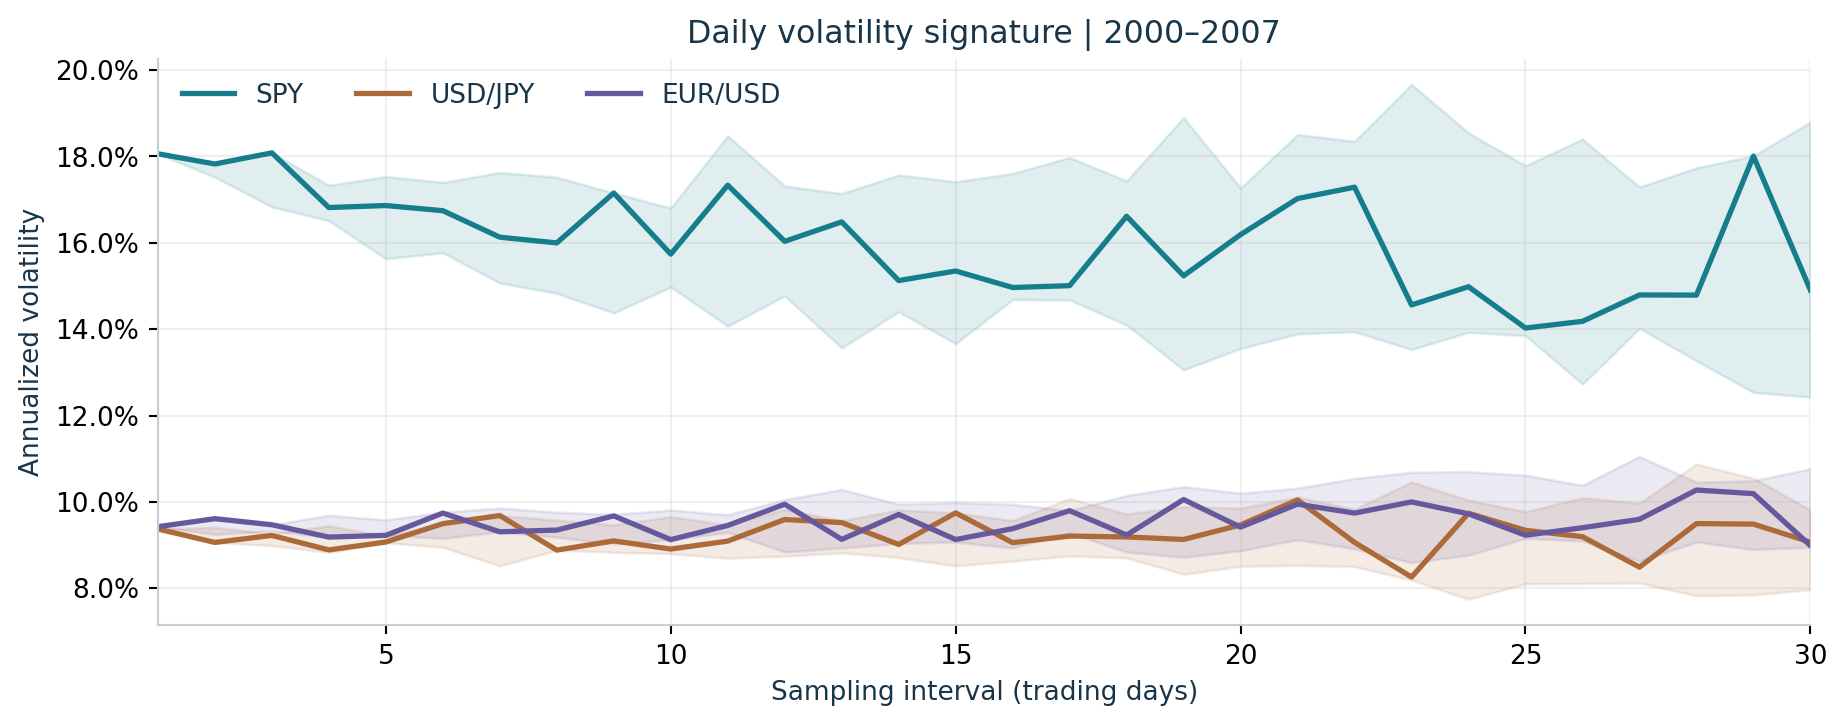

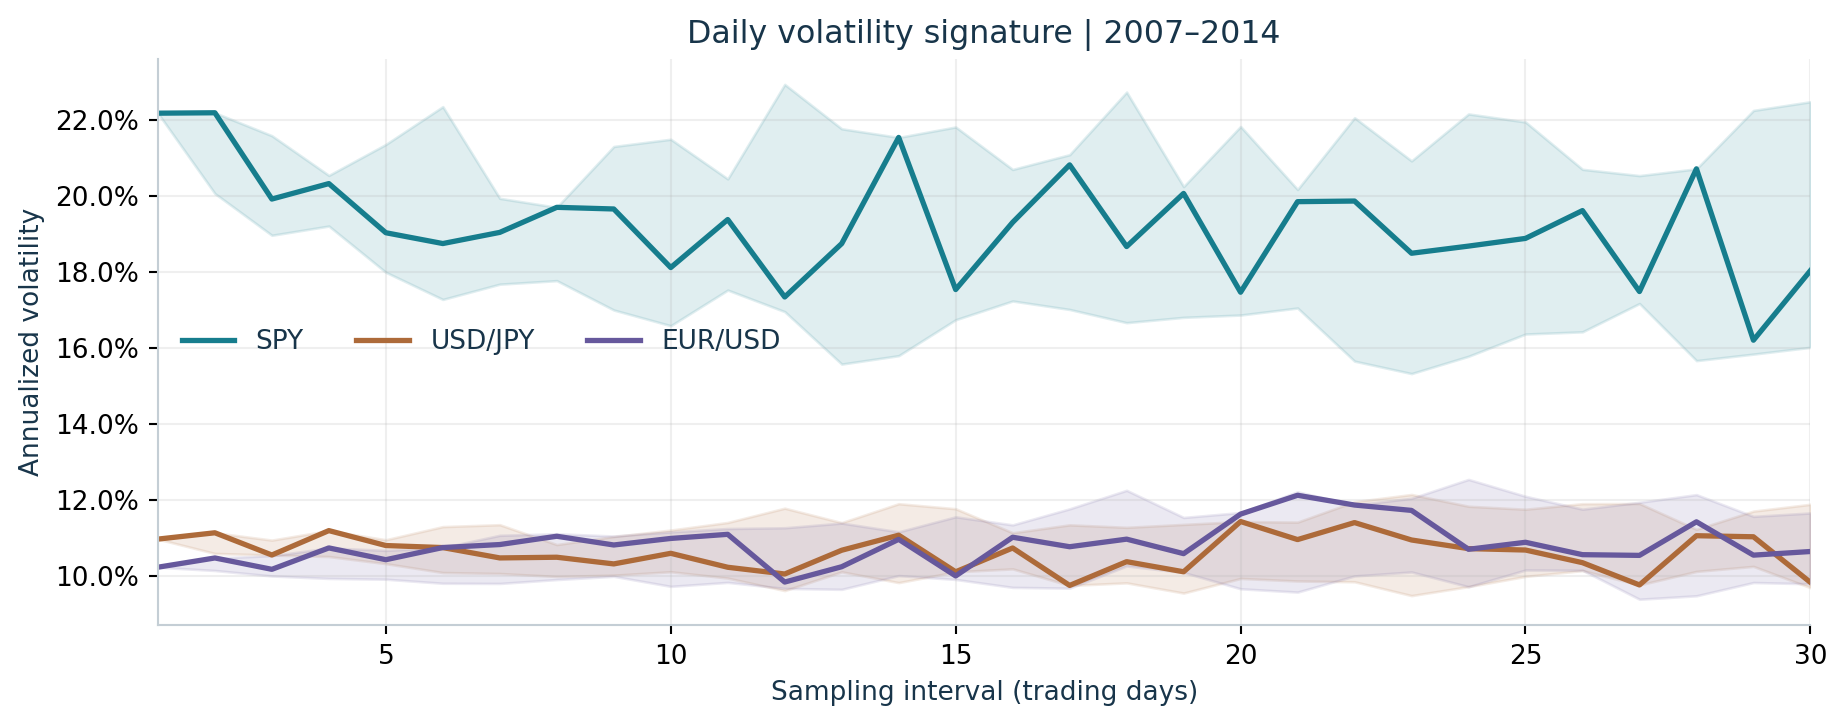

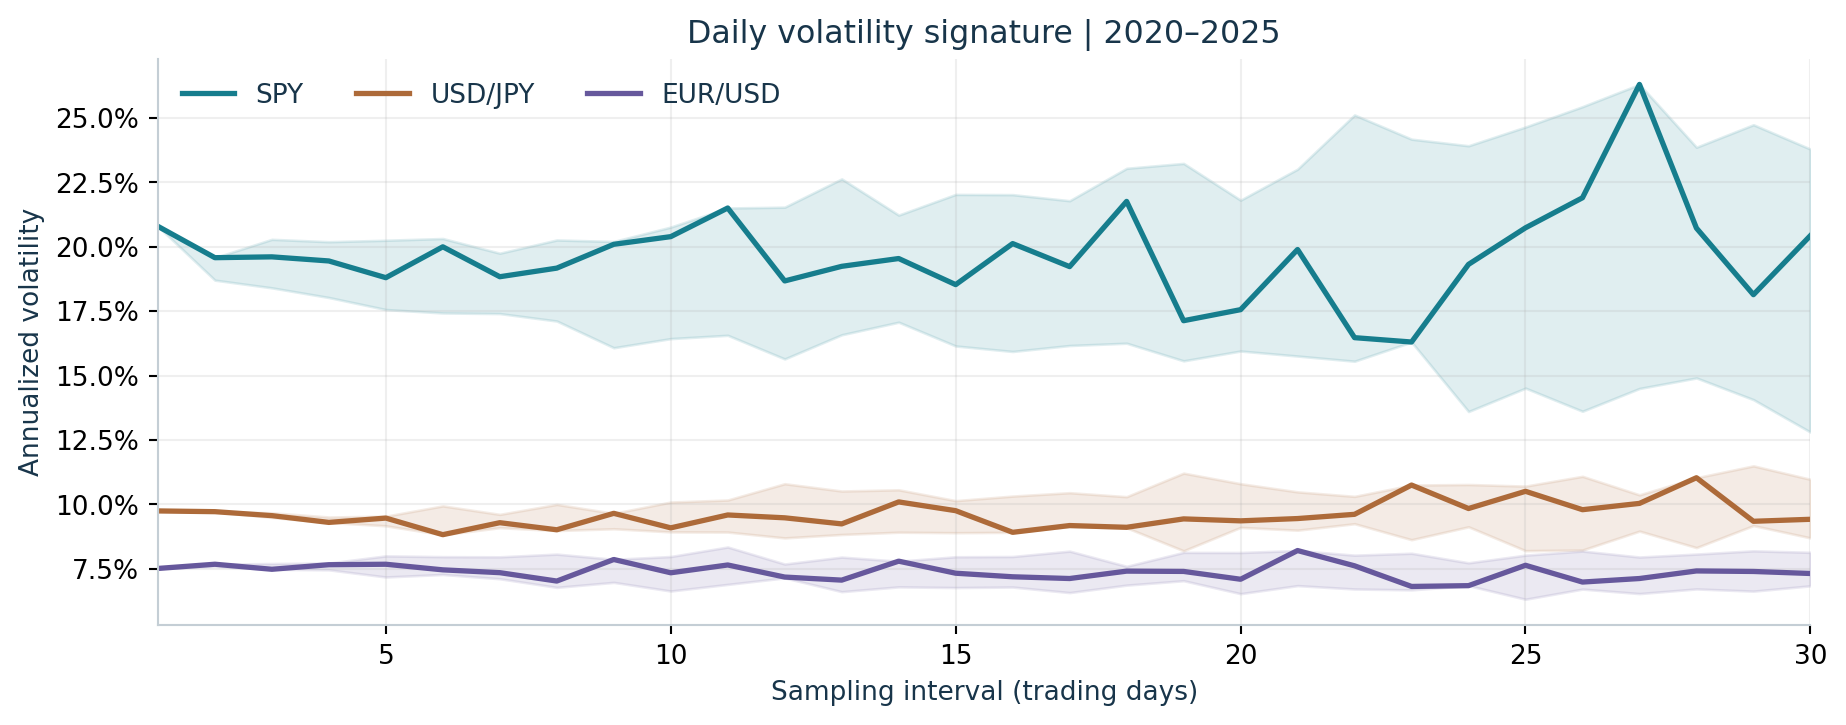

In [2]:
daily = table('daily_signatures')
for name in ['daily_2000_2007.png', 'daily_2007_2014.png', 'daily_2020_2025.png']:
    figure(name)

With independent returns of constant variance, rescaling by $\sqrt{252/k}$
produces a flat population signature. Dependence, changing volatility,
microstructure effects and finite-sample variation can make the observed curve
non-flat. For covariance-stationary one-day returns,

$$\frac{\operatorname{Var}(r_t+\cdots+r_{t-k+1})}{k}
=\gamma_0+2\sum_{j=1}^{k-1}\left(1-\frac{j}{k}\right)\gamma_j.$$

This identity describes population variance; the plotted demeaned finite-sample
estimators also depend on their sampling origin and sample size.

**Investment implication.** A sloped signature provides a hypothesis about
return dependence. It does not establish a cost-free arbitrage opportunity.
An execution rule must use information available before the trade and must
survive turnover and transaction costs.

## 3. Rolling daily-volatility distributions

Daily rolling estimates use 252-return windows. Each frequency uses a
nonoverlapping grid ending at the window's last observation. At $k=30$, there
are eight returns spanning the most recent 240 trading days; observations
outside the window are never added to enlarge the sample.

For every frequency, the table and figure report the mean, median, 25th
percentile and 75th percentile of the rolling estimates. Quantiles describe
variation across overlapping windows; they are not confidence intervals.
Rolling volatilities and their summaries remain in decimal annualized units
in the numerical table.

,step,mean,median,q25,q75,n_windows,asset,period
0,1,0.16346,0.13002,0.10727,0.22580,1758,SPY,2000–2007
1,2,0.16072,0.12424,0.10634,0.22501,1758,SPY,2000–2007
2,3,0.15736,0.12147,0.10298,0.21402,1758,SPY,2000–2007
3,4,0.15503,0.12486,0.10205,0.20961,1758,SPY,2000–2007
4,5,0.15340,0.12293,0.10049,0.20543,1758,SPY,2000–2007
5,6,0.15188,0.11831,0.10101,0.20411,1758,SPY,2000–2007
6,7,0.14997,0.11859,0.09831,0.20359,1758,SPY,2000–2007
7,8,0.14764,0.11631,0.09841,0.19866,1758,SPY,2000–2007
8,9,0.14640,0.11546,0.09778,0.20002,1758,SPY,2000–2007
9,10,0.14490,0.11688,0.09493,0.19444,1758,SPY,2000–2007


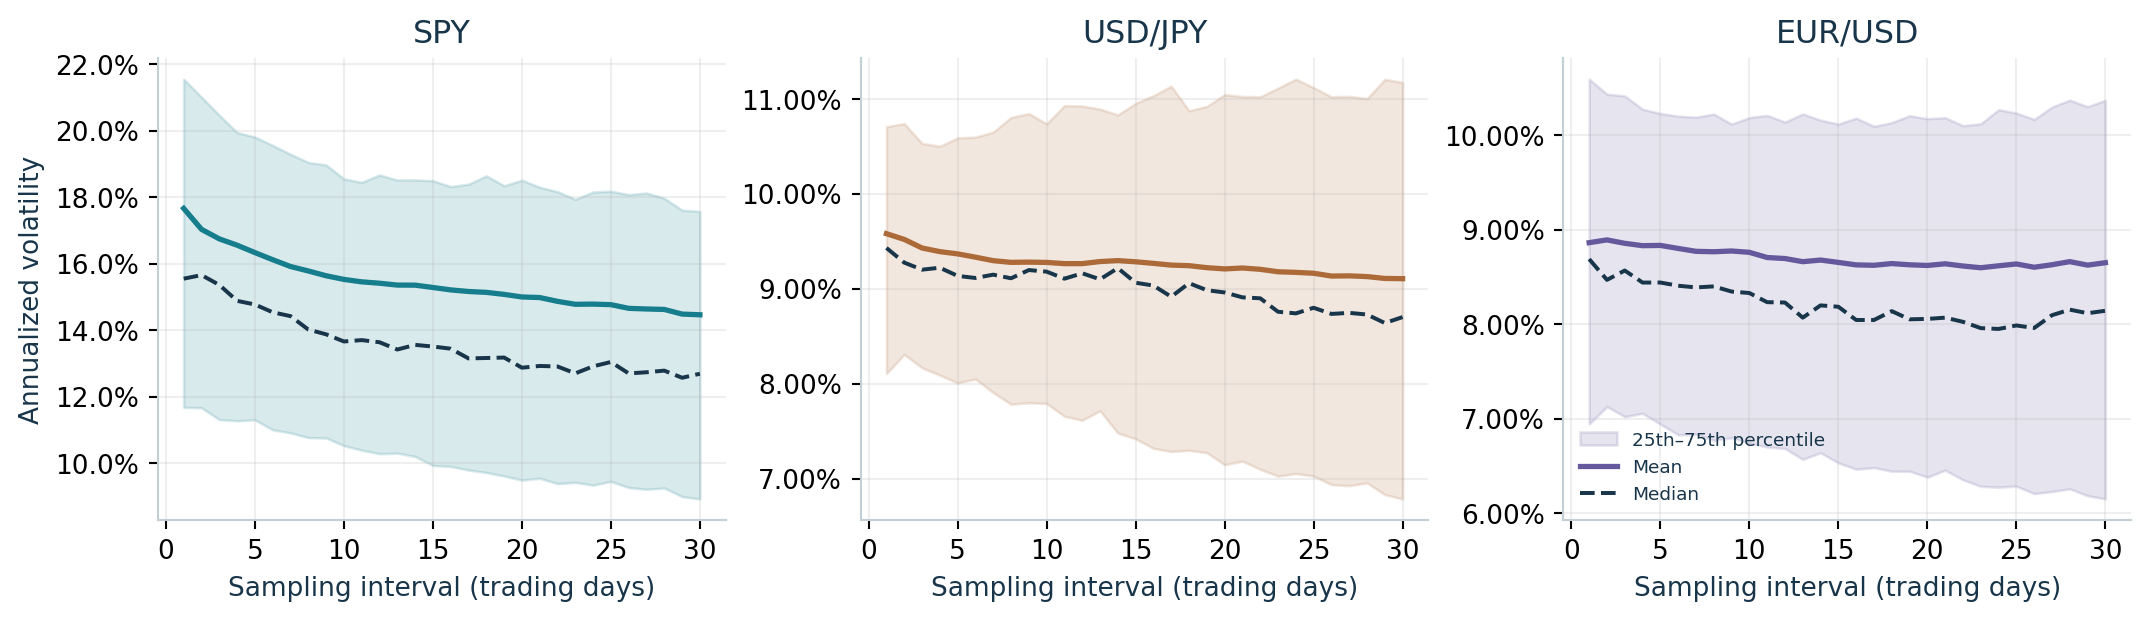

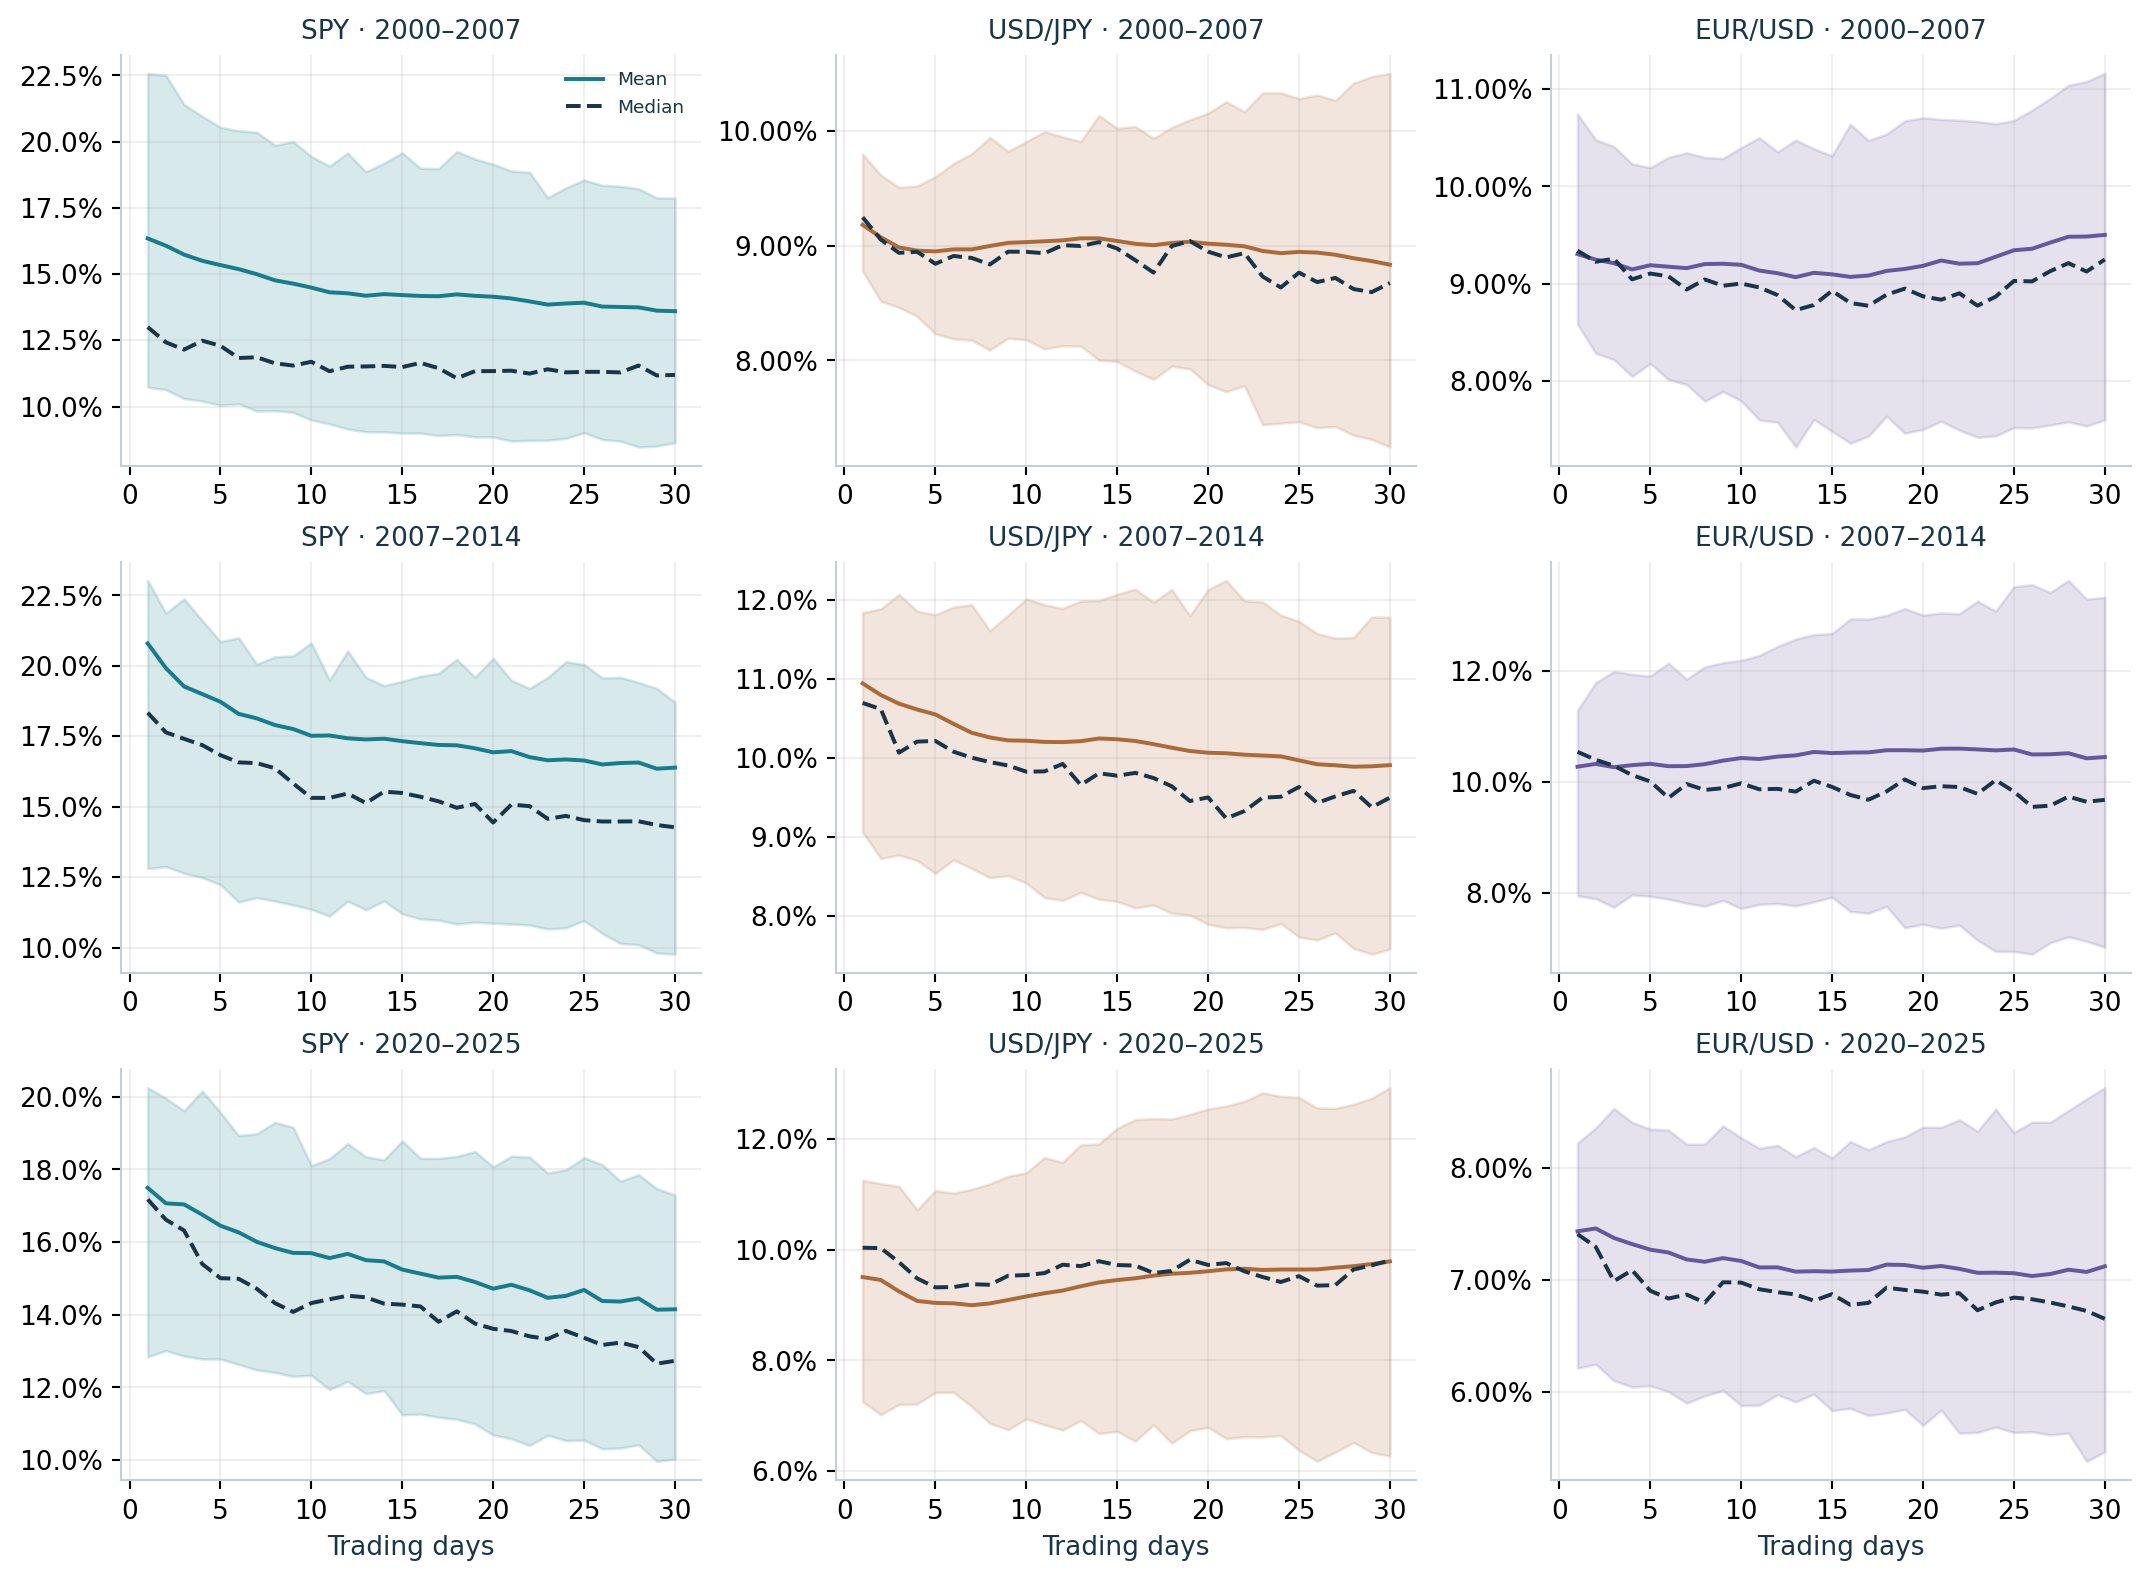

In [3]:
daily_dist = table('daily_distribution')
figure('daily_rolling_distribution.png')
figure('daily_rolling_by_period.png')

**Investment implication.** The spread of rolling estimates indicates how
unstable a fixed volatility target can be. Coarser frequencies have fewer
observations per window, so their apparent changes require particular care.
The median and interquartile range complement the mean when a few crisis
windows have unusually high volatility.

## 4. Intraday volatility signatures

For $h$ hours between observations and $H$ active hours per day, the assignment's
annualization rule is

$$\widehat\sigma_h=\operatorname{sd}_{n-1}(r^{(h)})
\sqrt{\frac{252H}{h}}.$$

The equivalent minute and second formulas are
$\operatorname{sd}(r^{(M)})\sqrt{15120H/M}$ and
$\operatorname{sd}(r^{(s)})\sqrt{907200H/s}$. The available hourly observations
support intervals of 1, 2, 3 and 6 hours over October 2024 through December 2025.
The separate shorter-history minute analysis in Section 5 resolves sub-hour
sampling; none of the inputs support second-level claims.

For US equities, $H=6.5$. Exact hourly equity marks run from 09:30 to 15:30
New York time. The last 30 minutes are excluded from hourly returns, while
the mandated annualization uses 6.5 active hours. No return crosses an
overnight closure. For currencies, $H=24$ and the main observation span is
00:00–18:00 UTC. Requiring all exact hourly marks in this common 18-hour span
allows Friday observations to be retained along with the other weekdays.
Annualization extrapolates the observed span to the stated active hours;
it does not imply that the omitted hours have been measured.

The intraday estimate is therefore an annualized within-session measure; it
does not include the equity overnight return. The audit and session counts
make the retained coverage explicit.

,hours,vol,n_returns,n_sessions,asset
0,1,0.13394,1854,309,SPY
1,2,0.13066,927,309,SPY
2,3,0.14912,618,309,SPY
3,6,0.15237,309,309,SPY
4,1,0.09948,5814,323,USDJPY
5,2,0.09917,2907,323,USDJPY
6,3,0.10029,1938,323,USDJPY
7,6,0.10327,969,323,USDJPY
8,1,0.08182,5814,323,EURUSD
9,2,0.08058,2907,323,EURUSD


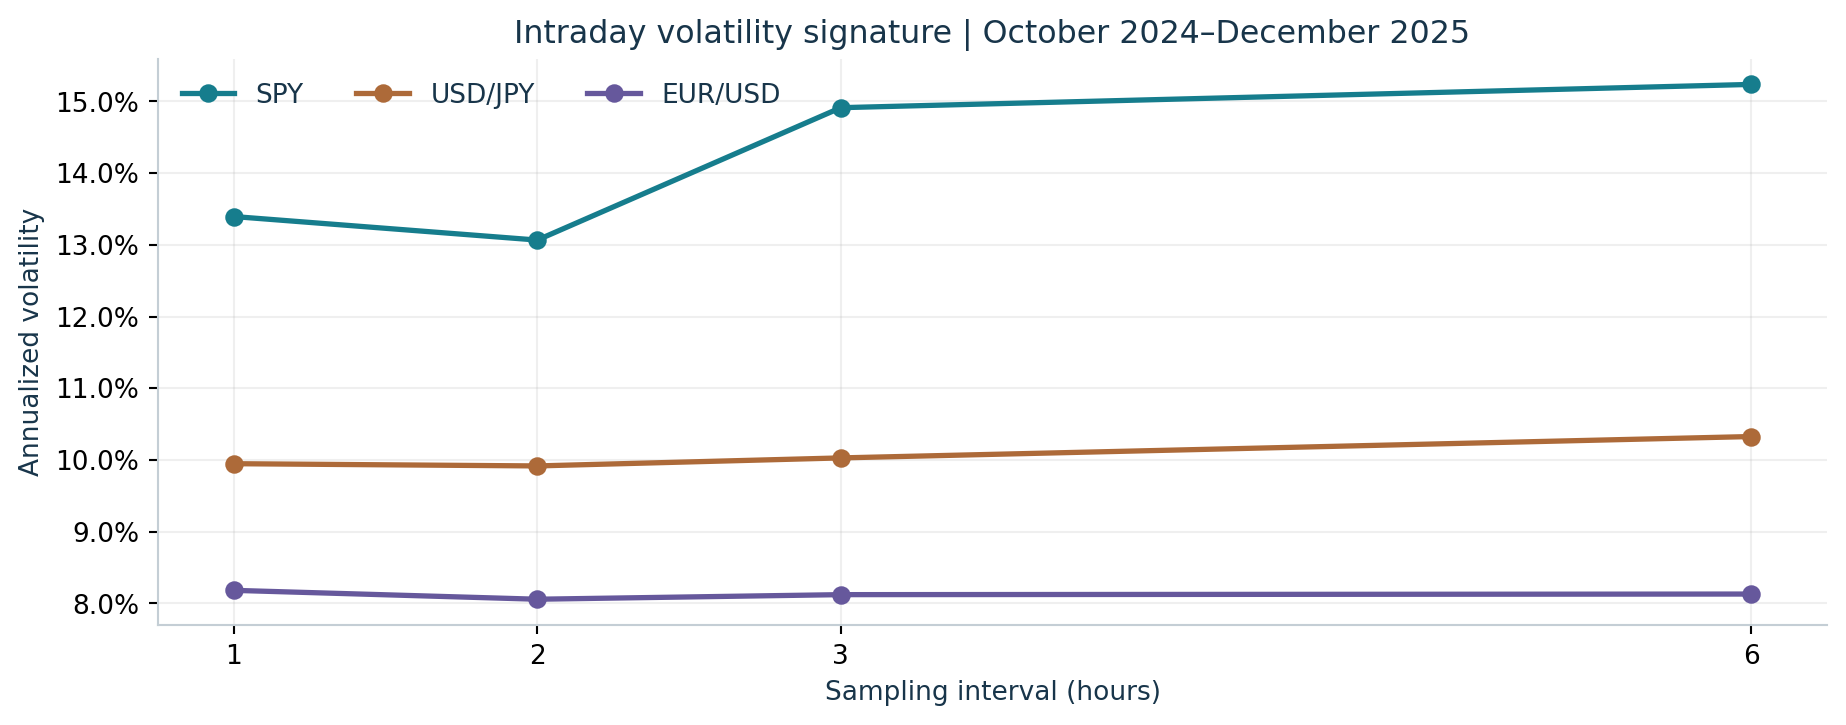

In [4]:
intraday = table('intraday_signatures')
figure('intraday_signature.png')

### 4.1. Session-definition sensitivity

The table compares the main 18-hour currency sample with complete 24-hour UTC
currency sessions. The latter predominantly retains Monday–Thursday because
Friday does not contain all 24 required hourly observations. Both the time span
and sample composition therefore change; the difference is not an isolated
estimate of the effect of the omitted six hours. SPY's six observed hours are
included for reference. Volatility is in annualized decimal units.

In [5]:
session_sensitivity = table('intraday_session_sensitivity')

,hours,vol,n_returns,n_sessions,asset,observed_hours
0,1,0.13394,1854,309,SPY,6
1,2,0.13066,927,309,SPY,6
2,3,0.14912,618,309,SPY,6
3,6,0.15237,309,309,SPY,6
4,1,0.09948,5814,323,USDJPY,18
5,2,0.09917,2907,323,USDJPY,18
6,3,0.10029,1938,323,USDJPY,18
7,6,0.10327,969,323,USDJPY,18
8,1,0.09064,6144,256,USDJPY,24
9,2,0.09026,3072,256,USDJPY,24


### 4.2. Rolling intraday distributions

The intraday windows span exactly six calendar months, with dates in
$(t-6\text{ months},t]$. A window is first available after six months of source
history. The number of retained complete sessions varies, and missing sessions
do not stretch the window's dates. Within each window, returns are pooled at
their stated frequency and annualized using the same estimator. The four
requested summaries are calculated separately for every asset and hourly
frequency; the data audit records the range of retained session counts.

,hours,mean,median,q25,q75,n_windows,asset
0,1,0.14756,0.17045,0.09638,0.17723,187,SPY
1,2,0.14433,0.16708,0.09147,0.17389,187,SPY
2,3,0.16671,0.19766,0.09887,0.20400,187,SPY
3,6,0.17147,0.20497,0.09978,0.21127,187,SPY
4,1,0.10468,0.11124,0.09563,0.11287,195,USDJPY
5,2,0.10402,0.10890,0.09766,0.11067,195,USDJPY
6,3,0.10515,0.11112,0.09665,0.11232,195,USDJPY
7,6,0.10896,0.11412,0.10169,0.11622,195,USDJPY
8,1,0.08799,0.09316,0.08015,0.09526,195,EURUSD
9,2,0.08727,0.09235,0.07996,0.09420,195,EURUSD


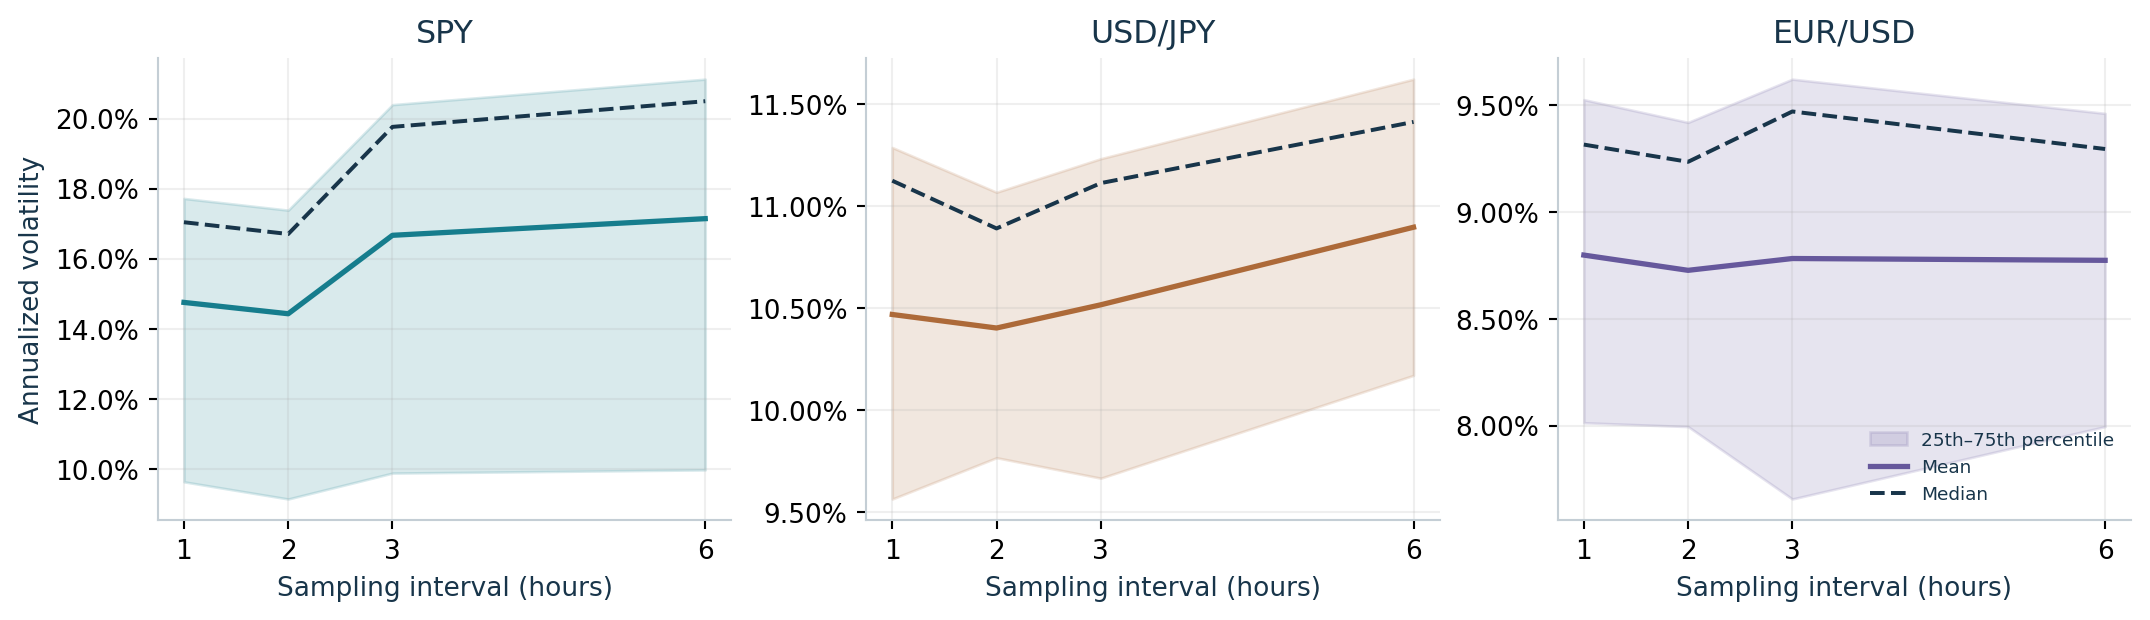

In [6]:
intraday_dist = table('intraday_distribution')
figure('intraday_rolling_distribution.png')

**Investment implication.** A different volatility estimate at different hours
may reflect serial dependence, the time of day sampled and changing activity.
The omitted equity intervals and the shorter available history limit a direct
comparison with full-day estimates. A trading decision needs the explicit
cash-flow test below.

## 5. Genuine minute-level data under the instructor's clarification

The instructor permits shorter minute-level history when its source and date
range are explicit. Yahoo Finance, accessed through `yfinance`, supplied the
longest one-minute and five-minute histories retrieved under the tested source
limits. Recorded older requests were rejected under Yahoo's 30-day one-minute
and 60-day five-minute restrictions. One-minute downloads were split into
batches of at most seven days. The complete-date cutoff is September 23, 2026;
these are the longest retrieved histories from this source, not a claim about
what every vendor offers.

**Usable return dates:** August 26 through September 23, 2026 for one-minute
source bars, and July 27 through September 23, 2026 for five-minute source bars.
The raw FX feeds begin on the preceding date after the selected 00:00-18:00 UTC
span. The coverage table distinguishes observed bar timestamps from usable
return timestamps, so those extra bars do not imply an extra analyzed session.
Exact request bounds, acquisition responses, cleaning and hashes are preserved
in `minute_data_manifest.json`.

In [7]:
minute_coverage = table('minute_coverage')

,asset,base_minutes,source,requested_start_utc,requested_end_exclusive_utc,observed_first_bar_utc,observed_last_bar_utc,n_bars,base_valid_returns,base_sessions,usable_first_return_utc,usable_last_return_utc,six_month_window_available
0,SPY,1,Yahoo Finance,2026-08-25T21:10:00Z,2026-09-24T00:00:00Z,2026-08-26T13:30:00+00:00,2026-09-23T19:59:00+00:00,7799,7198,20,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,False
1,SPY,5,Yahoo Finance,2026-07-26T21:10:00Z,2026-09-24T00:00:00Z,2026-07-27T13:30:00+00:00,2026-09-23T19:55:00+00:00,3276,3024,42,2026-07-27T13:30:00+00:00,2026-09-23T19:30:00+00:00,False
2,USDJPY,1,Yahoo Finance,2026-08-25T21:10:00Z,2026-09-24T00:00:00Z,2026-08-25T21:10:00+00:00,2026-09-23T23:59:00+00:00,29900,22680,21,2026-08-26T00:00:00+00:00,2026-09-23T18:00:00+00:00,False
3,USDJPY,5,Yahoo Finance,2026-07-26T21:10:00Z,2026-09-24T00:00:00Z,2026-07-26T23:00:00+00:00,2026-09-23T23:55:00+00:00,12208,9288,43,2026-07-27T00:00:00+00:00,2026-09-23T18:00:00+00:00,False
4,EURUSD,1,Yahoo Finance,2026-08-25T21:10:00Z,2026-09-24T00:00:00Z,2026-08-25T21:10:00+00:00,2026-09-23T23:59:00+00:00,29996,22632,21,2026-08-26T00:00:00+00:00,2026-09-23T18:00:00+00:00,False
5,EURUSD,5,Yahoo Finance,2026-07-26T21:10:00Z,2026-09-24T00:00:00Z,2026-07-26T23:00:00+00:00,2026-09-23T23:55:00+00:00,12252,9288,43,2026-07-27T00:00:00+00:00,2026-09-23T18:00:00+00:00,False


### 5.1. Estimator, observed blocks and session coverage

Yahoo timestamps identify bar starts, so each endpoint uses the bar's **open**.
The one-minute input supports 1, 2, 3, 5, 10, 15, 30, 60, 120, 180 and 360-minute
sampling; the longer five-minute input supports 5, 10, 15, 30, 60, 120, 180 and
360-minute sampling. Nonoverlapping blocks keep a fixed session-open anchor.
Every base-grid mark inside a block, including both endpoints, must be observed.
A missing mark rejects the affected block, while later blocks keep their
original anchors. There is no gap filling, overnight bridging or partial block.

SPY uses 09:30-15:30 New York time; currencies use 00:00-18:00 UTC on weekdays.
The shared spans let every tested frequency divide the session exactly.
Annualized sample volatility is

$$\widehat\sigma_M=\operatorname{sd}_{n-1}(r^{(M)})
\sqrt{\frac{15120H}{M}},\qquad H_{\rm SPY}=6.5,\quad H_{\rm FX}=24.$$

As with the hourly results, annualization extrapolates the observed within-day
variance rate to the stated active hours. These estimates do not include the
equity overnight return. The audit below aggregates daily availability by asset,
source resolution and sampling interval. A date with no mark inside the selected
span does not establish an observed session.

,base_minutes,interval_minutes,annualized_vol,n_returns,n_sessions,candidate_blocks,rejected_blocks,first_return_start_utc,last_return_end_utc,asset
0,1,1,0.06758,7198,20,7200,2,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
1,1,2,0.06742,3598,20,3600,2,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
2,1,3,0.06622,2398,20,2400,2,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
3,1,5,0.06845,1439,20,1440,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
4,1,10,0.06613,719,20,720,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
5,1,15,0.06986,479,20,480,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
6,1,30,0.07419,239,20,240,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
7,1,60,0.07901,119,20,120,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
8,1,120,0.08142,59,20,60,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY
9,1,180,0.07412,39,20,40,1,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,SPY


,asset,base_minutes,interval_minutes,observed_sessions,candidate_blocks,valid_blocks,rejected_blocks
0,EURUSD,1,1,21,22680,22632,48
1,EURUSD,1,2,21,11340,11300,40
2,EURUSD,1,3,21,7560,7527,33
3,EURUSD,1,5,21,4536,4509,27
4,EURUSD,1,10,21,2268,2243,25
5,EURUSD,1,15,21,1512,1488,24
6,EURUSD,1,30,21,756,732,24
7,EURUSD,1,60,21,378,354,24
8,EURUSD,1,120,21,189,165,24
9,EURUSD,1,180,21,126,102,24


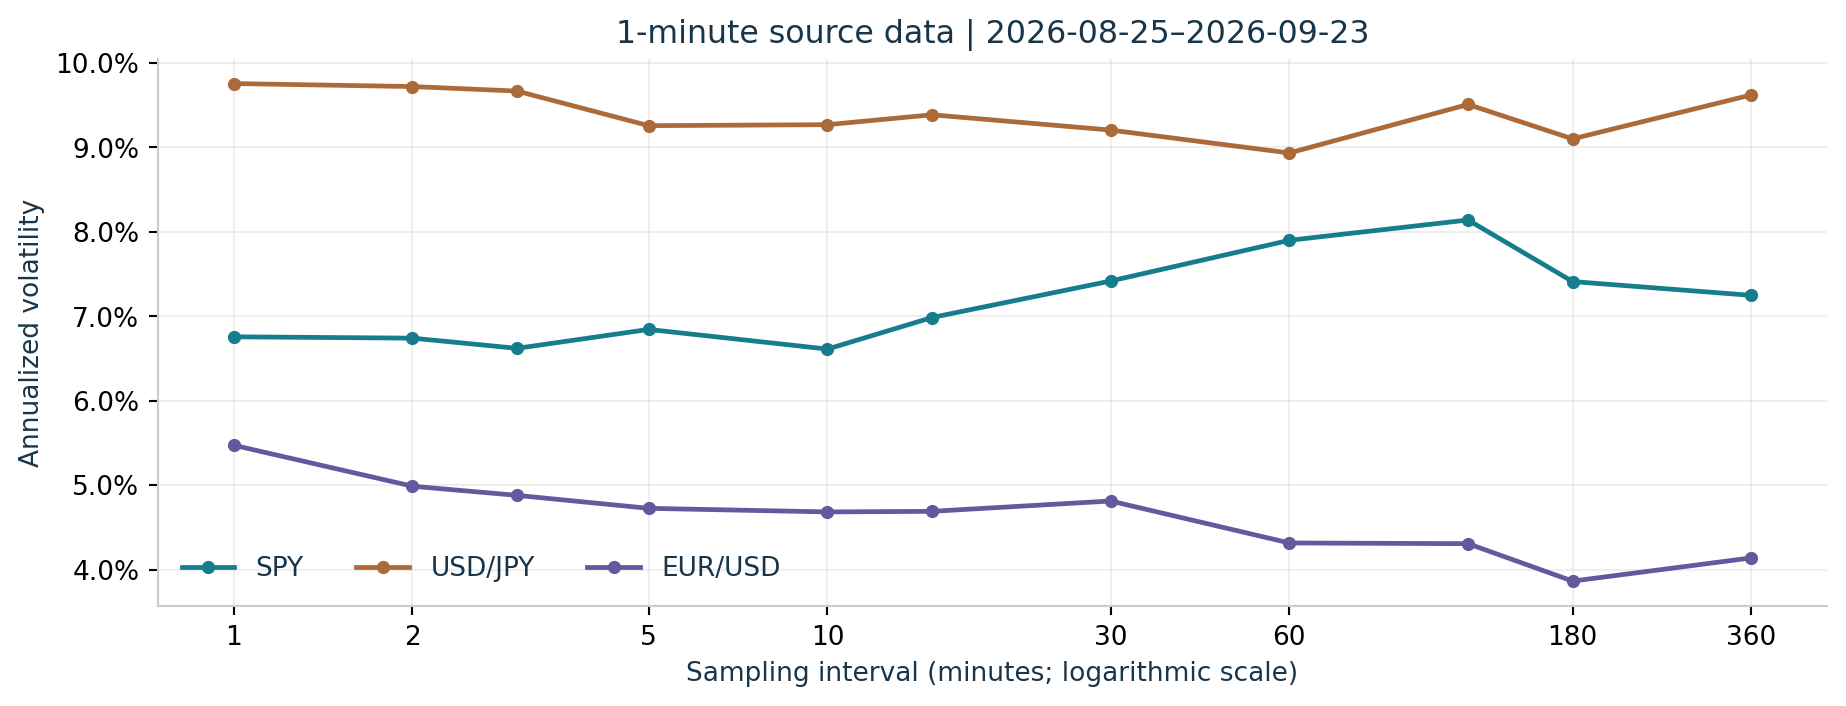

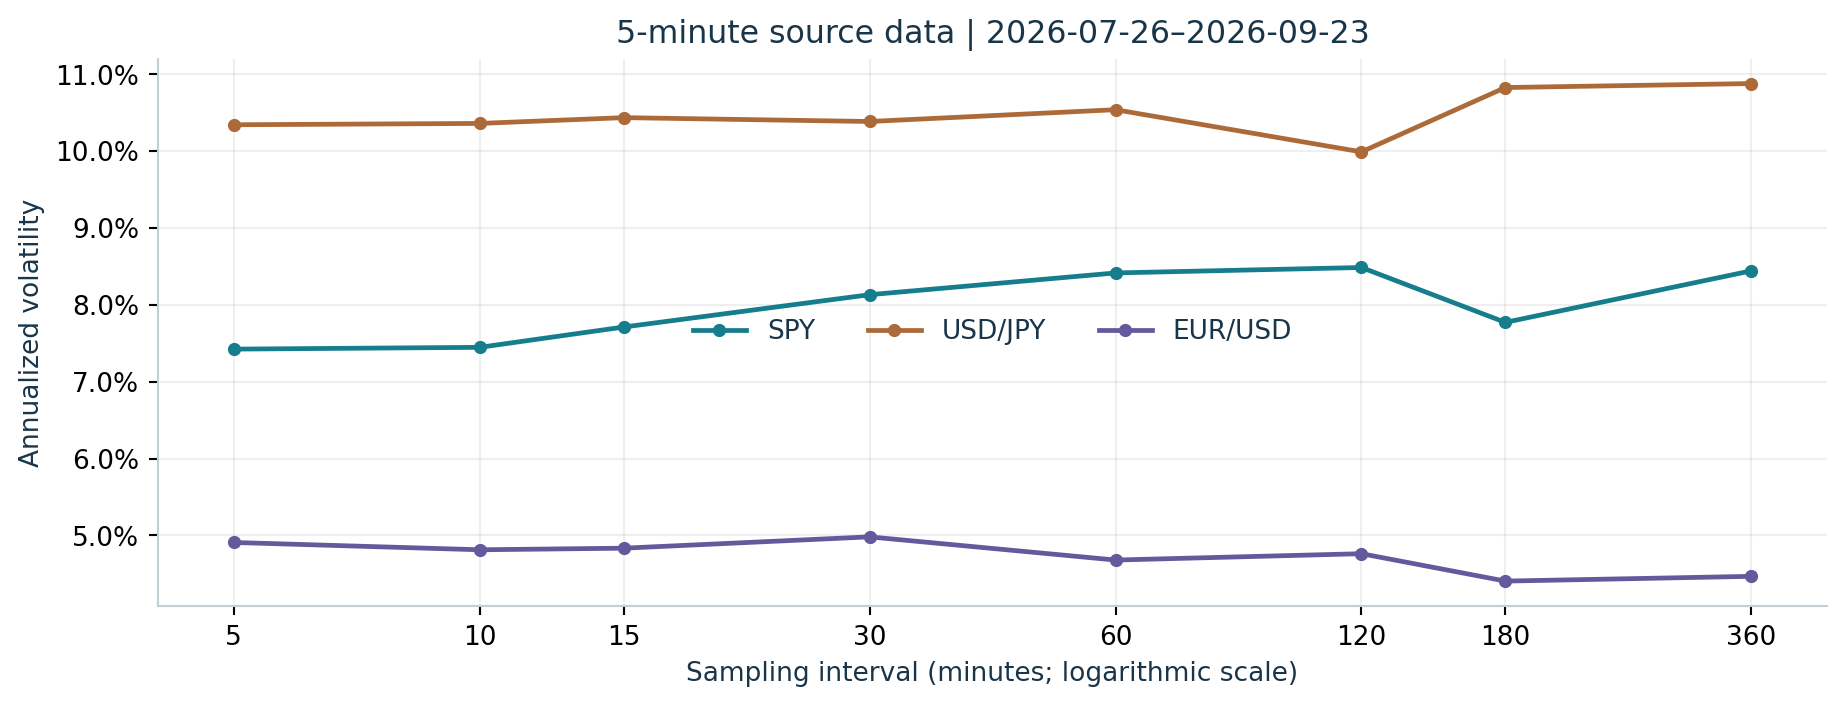

In [8]:
minute_signatures = table('minute_signatures')
minute_audit = pd.read_csv(OUT / 'minute_session_audit.csv')
display(minute_audit.groupby(['asset', 'base_minutes', 'interval_minutes']).agg(
    observed_sessions=('session', 'nunique'),
    candidate_blocks=('candidate_blocks', 'sum'),
    valid_blocks=('valid_blocks', 'sum'),
    rejected_blocks=('rejected_blocks', 'sum')).reset_index())
figure('minute_signature_1m.png')
figure('minute_signature_5m.png')

Missing marks change the sample composition across frequencies. For example,
EUR/USD's one-minute source supplies valid one-minute returns on 21 days, but
only 47 complete six-hour blocks across 16 days. A coarse-frequency slope can
therefore reflect both sampling frequency and the retained observations.
The one-minute and five-minute full-history curves also cover different dates;
their difference cannot isolate a source-resolution effect.

**Six-month rolling boundary.** Neither minute history spans six calendar
months. The requested six-month rolling mean, median and quartiles remain
available at 60, 120, 180 and 360 minutes from the longer hourly dataset in
Section 4. They are unavailable at minute-only frequencies with the retrieved
inputs. Shorter windows are not relabeled as six-month windows.

### 5.2. Compare both sources on identical five-minute blocks

The following check matches valid five-minute returns by their exact start and
end timestamps. It compares five-minute returns constructed from one-minute
opens with returns from native five-minute opens. This holds dates, clock times,
frequency and annualization fixed, separating feed consistency from the
different lengths of the full histories.

,asset,matched_returns,matched_sessions,first_start_utc,last_end_utc,vol_from_1m,vol_native_5m,correlation,mean_abs_return_difference_bps
0,SPY,1439,20,2026-08-26T13:30:00+00:00,2026-09-23T19:30:00+00:00,0.06845,0.06845,1.00000,0.00000
1,USDJPY,4536,21,2026-08-26T00:00:00+00:00,2026-09-23T18:00:00+00:00,0.09258,0.09258,1.00000,0.00000
2,EURUSD,4509,21,2026-08-26T00:00:00+00:00,2026-09-23T18:00:00+00:00,0.04727,0.04727,1.00000,0.00000


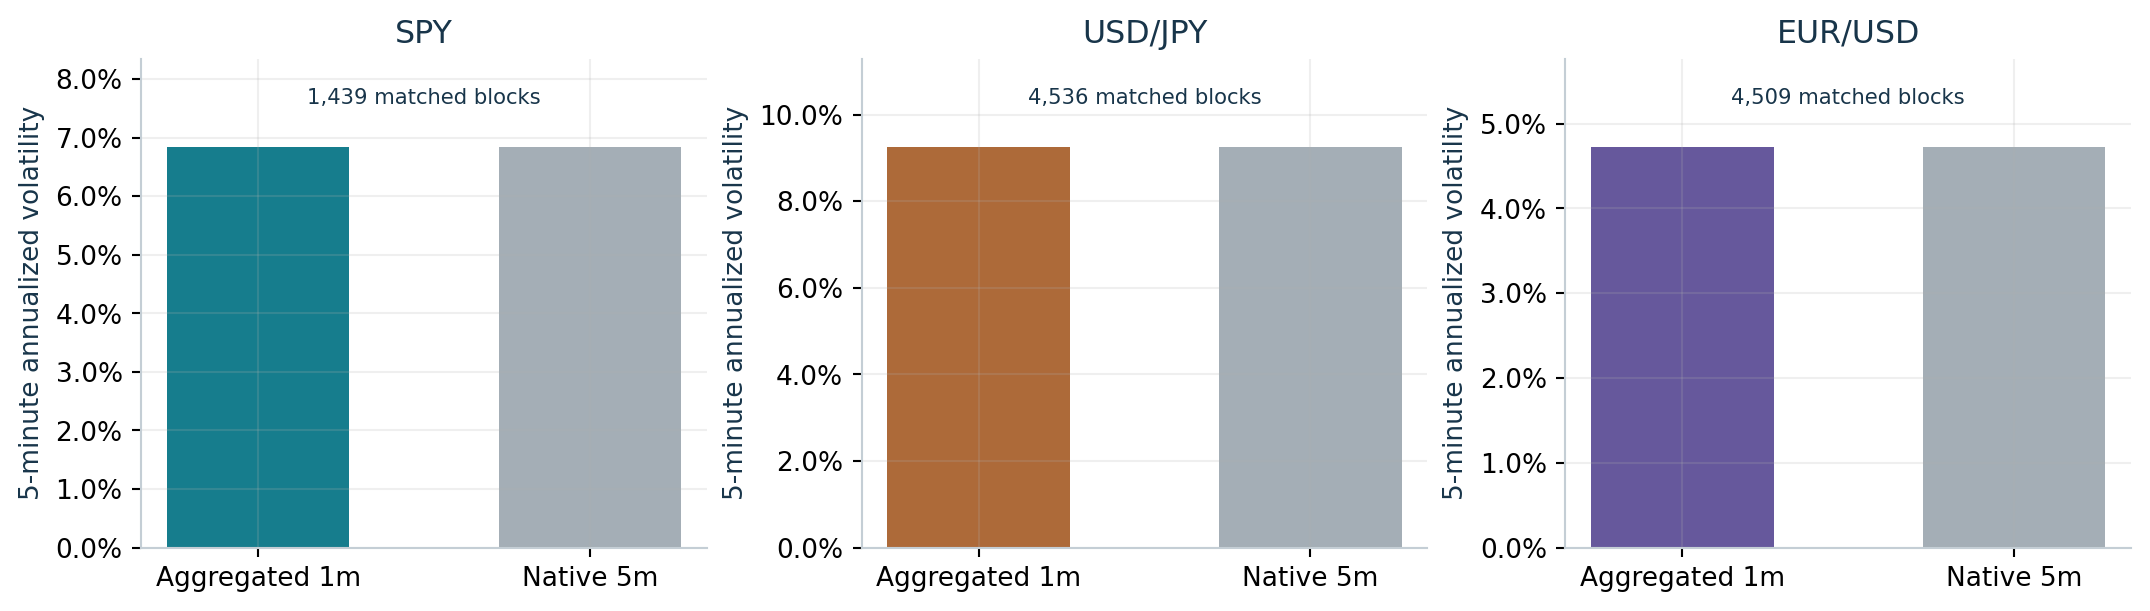

In [9]:
minute_comparison = table('minute_comparison')
figure('minute_comparison.png')

All three assets have identical stored returns on the matched blocks: the
return correlations are one and mean absolute differences are zero. This is an
internal consistency check on Yahoo's two resolutions, not independent vendor
validation. The short minute sample provides the requested finer-frequency
evidence, but does not establish a persistent tradable effect. The daily
2020-2025 trading specification below is not selected using these later data.

## 6. Frequency-arbitrage implementation

The supplied *Option Delta Hedging* reference motivates inverse-price holdings
and comparing two rebalancing frequencies. With fixed notional $N$, the combined
position after execution at time $t$ is

$$q_t=s_tN\left(\frac{1}{P_{f,t}}-\frac{1}{P_{s,t}}\right),$$

where $P_{f,t}$ and $P_{s,t}$ are the most recent fast and slow execution prices.
At the slow reset, both legs rebalance and their net holding is zero. The
orientation $s_t$ uses a trailing 252-return volatility comparison formed
strictly before the current execution price. Both sampling grids are aligned
to end at $t-1$. The main pair rebalances at one and five trading days.
The orientation is determined at each slow reset and frozen until the next
slow reset; it is not recomputed on the intervening daily rebalances.
LVD uses $s_t=\operatorname{sign}(\widehat\sigma_{1,t-1}-\widehat\sigma_{5,t-1})$;
HVD uses the opposite orientation. Both are reported without choosing the
better result after observing the evaluation period.

The change in equity includes the previous holding's price and dividend
cash flow, less the cost of the net change in shares:

$$E_t-E_{t-1}=q_{t-1}(S_t-S_{t-1}+D_t)
-cS_t\lvert q_t-q_{t-1}\rvert.$$

Here $c$ is a one-way proportional cost. Notional and initial equity are both
100,000 units of each asset's quote currency: USD for SPY and EUR/USD, JPY for
USD/JPY. Percentage returns are normalized within each account; USD/JPY is not
presented as a funded USD-account return. The cash account earns zero,
notional and starting capital are fixed, and terminal liquidation is charged.
Netting simultaneous opposite orders gives a favorable transaction-cost
assumption. The strategy is evaluated as a capital-funded backtest; the
volatility signature alone is not treated as a guaranteed profit.

,asset,strategy,cost_bps,total_return,cagr,ann_vol,sharpe_zero_rate,max_drawdown,annual_turnover,cost_quote_units,gross_pnl_quote_units,net_pnl_quote_units,max_abs_exposure
0,SPY,LVD,1,-0.00206,-0.00035,0.00724,-0.04402,-0.01623,2.52472,150.98219,-55.17049,-206.15268,0.17156
1,SPY,HVD,1,-0.00096,-0.00016,0.00735,-0.01813,-0.01796,2.52472,150.98219,55.17049,-95.81169,0.17156
2,SPY,Buy and hold,0,1.29064,0.14866,0.20748,0.77216,-0.33717,0.00000,0.00000,"129,063.63166","129,063.63166",1.00000
3,USDJPY,LVD,1,-0.00166,-0.00027,0.00098,-0.27299,-0.00349,1.29598,80.27878,-85.83617,-166.11495,0.04641
4,USDJPY,HVD,1,0.00006,0.00001,0.00098,0.00965,-0.00199,1.29598,80.27878,85.83617,5.55739,0.04641
5,USDJPY,Buy and hold,0,0.43919,0.06054,0.09349,0.67551,-0.14749,0.00000,0.00000,"43,919.35549","43,919.35549",1.00000
6,EURUSD,LVD,1,0.00080,0.00013,0.00060,0.21525,-0.00106,1.06359,65.88336,145.50988,79.62651,0.03571
7,EURUSD,HVD,1,-0.00211,-0.00034,0.00060,-0.57034,-0.00230,1.06359,65.88336,-145.50988,-211.39324,0.03571
8,EURUSD,Buy and hold,0,0.04692,0.00743,0.07493,0.13622,-0.22242,0.00000,0.00000,"4,691.86826","4,691.86826",1.00000


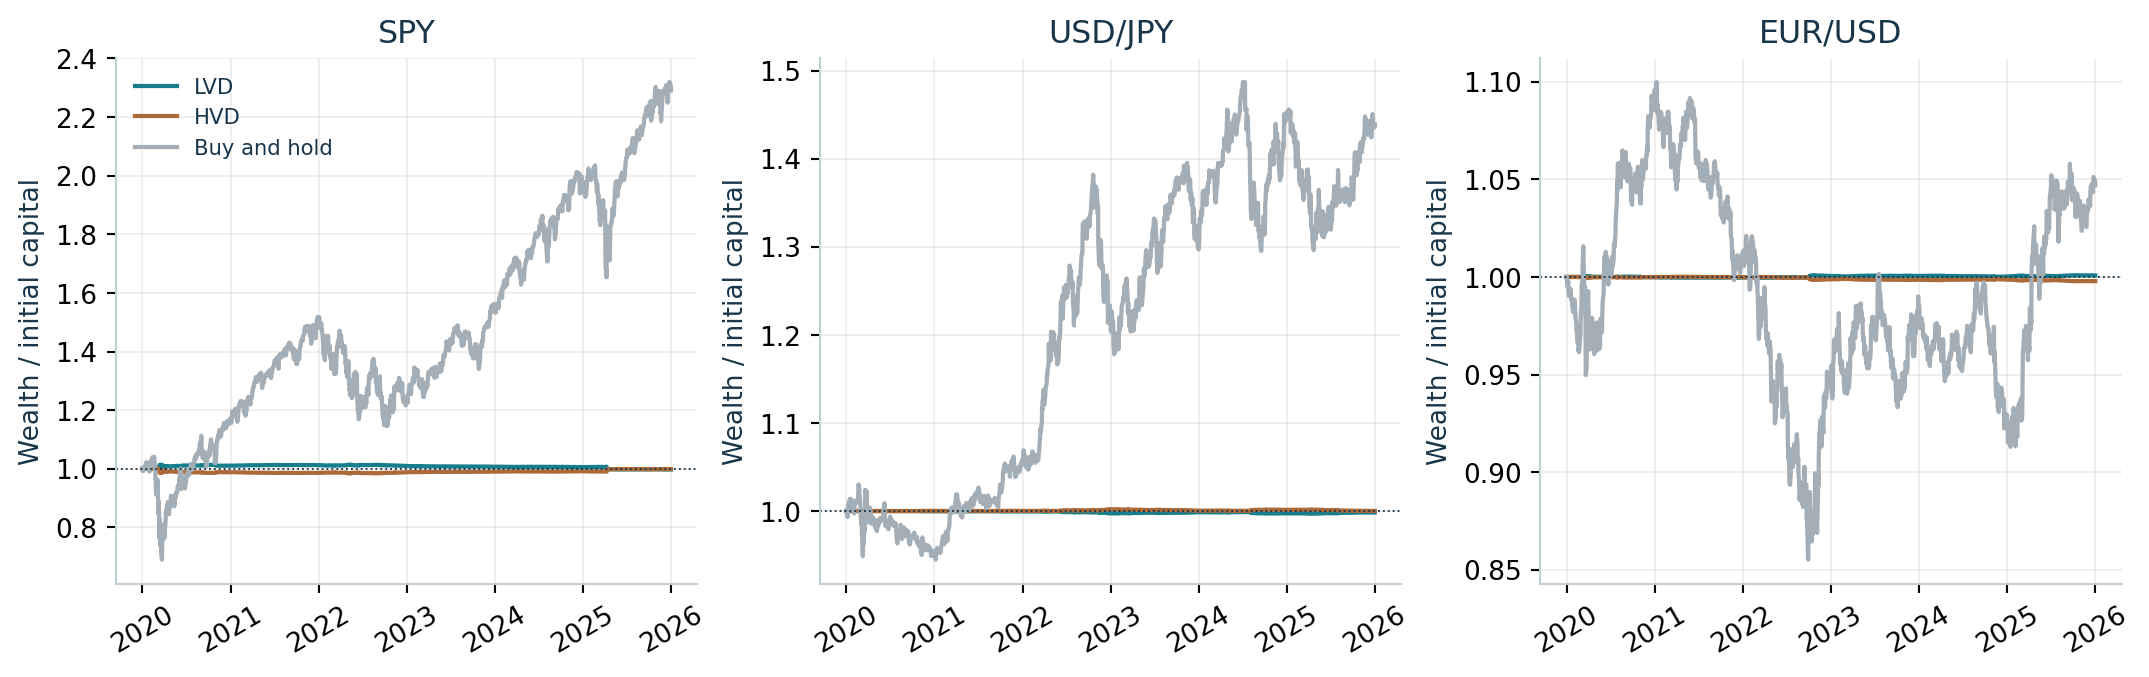

In [10]:
strategy = table('strategy_metrics')
figure('strategy_equity.png')

### 6.1. Transaction costs and specification sensitivity

The main metrics compare both orientations. The sensitivity table varies the
LVD slow frequency across 5, 10 and 20 days, with the fast frequency held at
one day, and costs across 0, 1, 5 and 10 basis points per side.
Return and volatility metrics use the units stated in their
column names; decimal returns translate to percentages by multiplying by 100.
The zero-rate Sharpe ratio uses realized daily strategy returns, with 252
trading days per year. Drawdown is measured from the running equity maximum,
including initial capital.

These specifications are robustness comparisons, not an out-of-sample search
for the best historical combination. Cash financing, short-sale constraints,
foreign-exchange funding and executable spreads must be considered before
moving from this simplified experiment to trading.

,asset,slow_days,cost_bps,total_return,cagr,ann_vol,sharpe_zero_rate,max_drawdown,annual_turnover,cost_quote_units,gross_pnl_quote_units,net_pnl_quote_units,max_abs_exposure
0,SPY,5,0,-0.00055,-0.00009,0.00724,-0.00913,-0.01547,2.52472,0.00000,-55.17049,-55.17049,0.17156
1,SPY,5,1,-0.00206,-0.00035,0.00724,-0.04402,-0.01623,2.52472,150.98219,-55.17049,-206.15268,0.17156
2,SPY,5,5,-0.00810,-0.00136,0.00726,-0.18368,-0.02172,2.52472,754.91094,-55.17049,-810.08143,0.17156
3,SPY,5,10,-0.01565,-0.00263,0.00729,-0.35841,-0.02865,2.52472,"1,509.82187",-55.17049,"-1,564.99237",0.17156
4,SPY,10,0,0.00042,0.00007,0.01244,0.01183,-0.01919,2.57325,0.00000,41.76215,41.76215,0.19729
5,SPY,10,1,-0.00112,-0.00019,0.01244,-0.00887,-0.02029,2.57325,153.88431,41.76215,-112.12216,0.19729
6,SPY,10,5,-0.00728,-0.00122,0.01244,-0.09193,-0.02471,2.57325,769.42153,41.76215,-727.65939,0.19729
7,SPY,10,10,-0.01497,-0.00252,0.01245,-0.19637,-0.03024,2.57325,"1,538.84306",41.76215,"-1,497.08092",0.19729
8,SPY,20,0,-0.01065,-0.00179,0.01888,-0.08529,-0.04199,2.54595,0.00000,"-1,064.60455","-1,064.60455",0.27869
9,SPY,20,1,-0.01217,-0.00205,0.01889,-0.09890,-0.04323,2.54595,152.25172,"-1,064.60455","-1,216.85627",0.27869


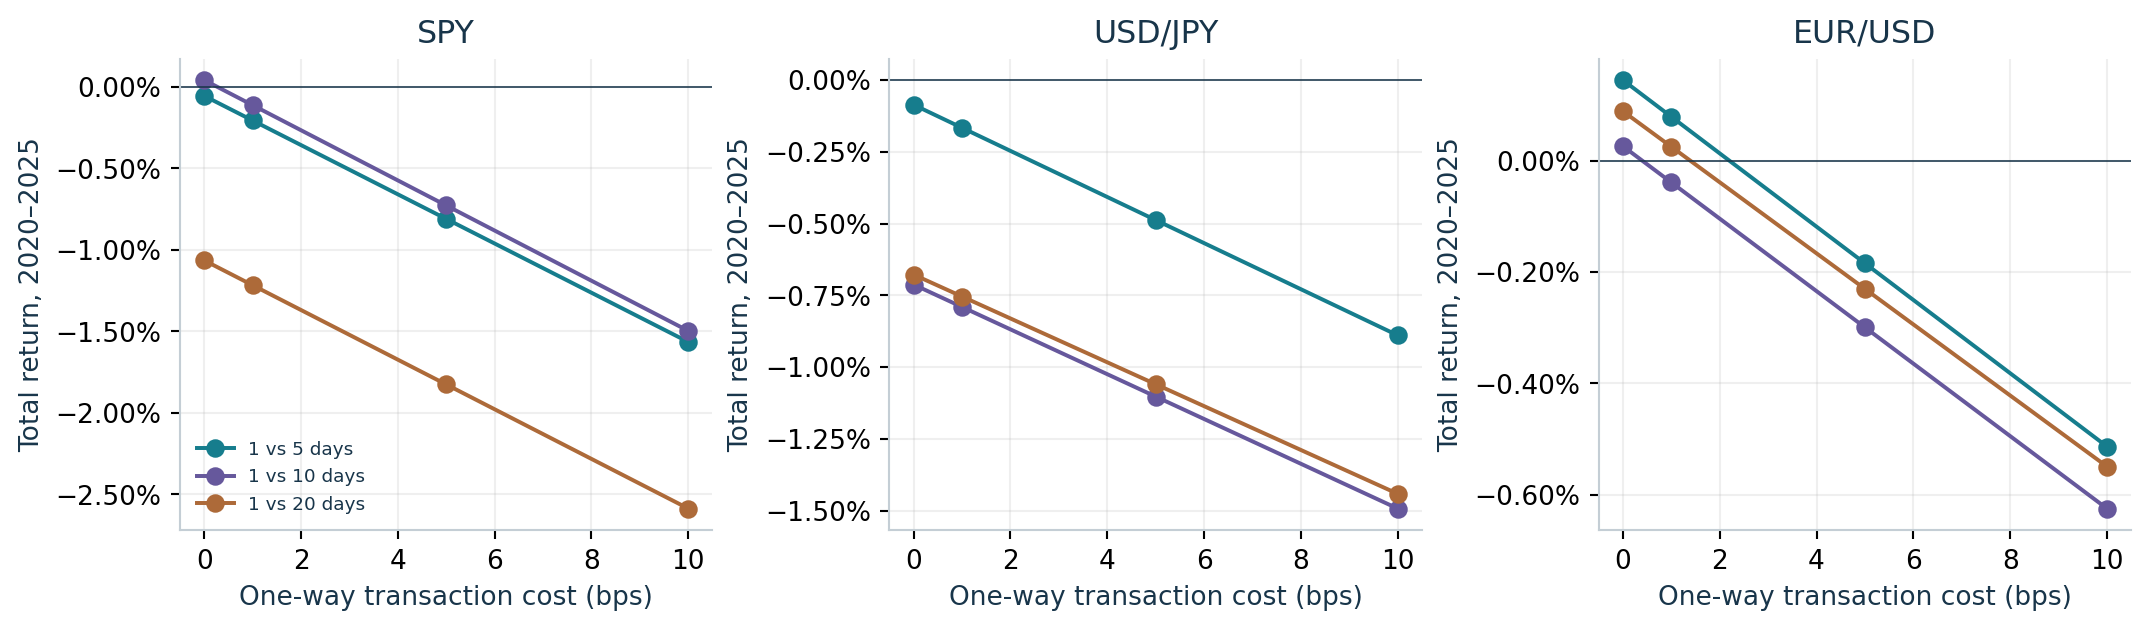

In [11]:
sensitivity = table('strategy_sensitivity')
figure('strategy_costs.png')

## 7. Investment decision and limitations

The practical decision rests on realized net cash flows and their sensitivity
to costs, rather than the visual distance between signature curves. The
following comparison reports the main one-versus-five-day LVD strategy at
zero cost, one basis point and ten basis points. The HVD result at one basis
point is shown alongside it. A positive gross result that disappears at a
small cost does not support implementation. A surviving historical result
still needs independent testing and realistic execution assumptions.

In [12]:
decision_rows = []
for asset in strategy['asset'].drop_duplicates():
    main = sensitivity[(sensitivity.asset == asset) & (sensitivity.slow_days == 5)]
    costs = main.set_index('cost_bps').total_return
    opposite = strategy[(strategy.asset == asset) & (strategy.strategy == 'HVD')].iloc[0]
    decision_rows.append({'asset': asset,
                          'LVD gross return (%)': 100 * costs.loc[0],
                          'LVD at 1 bp (%)': 100 * costs.loc[1],
                          'LVD at 10 bps (%)': 100 * costs.loc[10],
                          'HVD at 1 bp (%)': 100 * opposite.total_return})
decision = pd.DataFrame(decision_rows)
display(decision)
profitable_base = int((decision['LVD at 1 bp (%)'] > 0).sum())
profitable_stress = int((decision['LVD at 10 bps (%)'] > 0).sum())
display(Markdown(
    f'The main LVD strategy has a positive total return for **{profitable_base} of '
    f'{len(decision)} assets** at one basis point and **{profitable_stress} of '
    f'{len(decision)} assets** at ten basis points. '
    '**Decision:** keep this strategy as a research specification and do not '
    'allocate live capital from this experiment alone. The evidence does not '
    'establish a reliable advantage across assets and execution conditions; '
    'the opposite orientation and alternative frequencies are comparisons, '
    'not an independently validated trading rule.'))

,asset,LVD gross return (%),LVD at 1 bp (%),LVD at 10 bps (%),HVD at 1 bp (%)
0,SPY,-0.05517,-0.20615,-1.56499,-0.09581
1,USDJPY,-0.08584,-0.16611,-0.88862,0.00556
2,EURUSD,0.14551,0.07963,-0.51332,-0.21139


The main LVD strategy has a positive total return for **1 of 3 assets** at one basis point and **0 of 3 assets** at ten basis points. **Decision:** keep this strategy as a research specification and do not allocate live capital from this experiment alone. The evidence does not establish a reliable advantage across assets and execution conditions; the opposite orientation and alternative frequencies are comparisons, not an independently validated trading rule.

The main limits are the different daily and intraday histories, omitted
overnight equity returns in the intraday estimator, sampling-origin variation,
overlapping rolling windows, sparse coarse-frequency estimates, and the
stylized cost and financing model. No result is a promised future return.

## 8. Reproducibility and verification

`src/analysis.py` contains the daily/hourly estimators and trading ledger;
`src/minute_analysis.py` contains the observed minute-block estimators.
`scripts/run_analysis.py` builds the tables and figures.
The 45 focused tests check estimator arithmetic, session boundaries, lagged
execution, turnover, cash-flow accounting, input integrity and minute-gap
handling using explicitly synthetic examples.
The figures embedded here are generated exhibits, and the repository contains
no downloaded market-data files. Input coverage and source provenance are
recorded by the acquisition pipeline. The LaTeX report and its figures provide
a standalone submission artifact.

In [13]:
required = ['daily_signatures', 'daily_distribution', 'intraday_signatures',
            'intraday_distribution', 'data_audit', 'strategy_metrics',
            'strategy_sensitivity', 'intraday_session_sensitivity',
            'minute_coverage', 'minute_signatures', 'minute_comparison',
            'minute_session_audit']
for name in required:
    assert (OUT / (name + '.csv')).is_file()
print(f'Verified {len(required)} generated result tables and all displayed figures.')
print('Notebook calculations completed without replacing missing results.')

Verified 12 generated result tables and all displayed figures.
Notebook calculations completed without replacing missing results.
